# Etapa 1 — EDA da Base Bank Marketing

Análise exploratória da base [`bank-marketing`](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing) (Kaggle, henriqueyamahata), utilizada como referência factual para o desafio de experimentação adaptativa. A base contém registros de campanhas de telemarketing de um banco português (Moro et al., 2014), oferecendo um produto de depósito a prazo.

Objetivos desta etapa: entender a estrutura da base, tratar valores especiais (`"unknown"`, sentinela `999`) e identificar colunas com vazamento temporal.


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import kagglehub
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
print(path)

/home/jonatas-locateli/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1


In [64]:
import os

for f in os.listdir(path):
    print(f)

bank-additional-full.csv
bank-additional-names.txt


In [65]:
import pandas as pd
import os

csv_path = os.path.join(path, "bank-additional-full.csv")
df = pd.read_csv(csv_path, sep=";")

df.shape


(41188, 21)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [67]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [68]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Desbalanceamento da variável-alvo

Verificando a proporção de clientes que converteram (`y = yes`) vs. não converteram.


In [69]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

**Achado:** apenas **11.3%** dos clientes converteram (`y = yes`) contra **88.7%** que não converteram. Esse desbalanceamento é relevante para o desenho do baseline (Etapa 3) e para a simulação dos braços do bandit (Etapa 2) — estamos lidando com um evento relativamente raro.

## Investigando valores "unknown"

A base usa a string `"unknown"` como categoria em várias colunas categóricas, em vez de deixar o campo vazio (NaN) — por isso `df.info()` não aponta nenhum valor nulo, mas isso não significa que os dados estão completos. Vamos mapear a extensão desse problema.


In [70]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} ({pct:.2f}%)")

job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


**Resultado:** seis colunas têm "unknown". Cinco delas (`job`, `marital`, `education`, `housing`, `loan`) têm proporção baixa (< 5%) — decisão: manter "unknown" como categoria própria nessas colunas, sem remover linhas ou imputar valores (evita introduzir viés e perda de dado real de outras colunas).

A exceção é `default`, com **20.87%** de "unknown" — proporção alta demais para ignorar sem investigar. Vamos checar se esse "unknown" carrega sinal real, comparando a taxa de conversão por grupo.


In [71]:
df.groupby('default')['y'].value_counts(normalize=True).unstack()

y,no,yes
default,,
no,0.87121,0.12879
unknown,0.94847,0.05153
yes,1.00000,NaN


**Achado importante:** clientes com `default = unknown` convertem a **menos da metade** da taxa de `default = no` (5.15% vs 12.88%). Ou seja, "unknown" aqui **não é neutro** — carrega sinal real (esse segmento pode ser menos "bancarizado" ou ter relação mais distante com a instituição).

Antes de tirar conclusões sobre `default = yes` (100% "no" na tabela acima), vale checar quantos casos existem — um percentual "gritante" pode ser só ruído de amostra pequena.


In [72]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

**Confirmado:** `default = yes` tem apenas **3 casos** em 41.188 — amostra estatisticamente insignificante, não usamos essa fatia para tirar conclusões. Já `default = unknown` (8.597 casos) é robusto o suficiente para o achado acima ser considerado válido.

**Decisão final sobre `default`:** mantido como categoria própria (mesma decisão técnica das outras 5 colunas), mas documentando que essa não foi uma escolha neutra — é uma escolha informada pela análise, permitindo que o modelo aprenda que "não sabemos o status de crédito" é, por si só, uma informação relevante.

## Tratando o valor-sentinela em `pdays`

No `describe()` anterior, os percentis 25%, 50% e 75% de `pdays` eram todos **999** — sinal de que a maioria da base compartilha esse valor artificial (não representa "999 dias reais"). Vamos confirmar a extensão exata.


In [73]:
(df['pdays'] == 999).sum()
(df['pdays'] == 999).mean() * 100

np.float64(96.32174419733903)

**Confirmado:** 96.32% da base tem `pdays = 999` (nunca contatada antes desta campanha). Um valor tão dominante distorceria qualquer estatística se tratado como número comum (outlier artificial).

**Decisão:** substituir a informação bruta por um indicador binário mais informativo — `contatado_antes` — capturando o que realmente importa (contato prévio ou não), sem carregar o ruído do sentinela.


In [74]:
df['contatado_antes'] = (df['pdays'] != 999).astype(int)

In [75]:
df['contatado_antes'].value_counts()

contatado_antes
0    39673
1     1515
Name: count, dtype: int64

Confirmado: 39.673 clientes (96.32%) nunca contatados vs. 1.515 (3.68%) já contatados — bate exatamente com o percentual calculado acima.

## Confirmando o vazamento temporal em `duration`

O enunciado do Datathon já avisa: `duration` (duração da ligação) é vazamento temporal — só existe *depois* da ligação acontecer, então não pode ser usada para decidir a oferta *antes* da ligação. Vamos comprovar isso com dados, comparando a duração média por resultado.


In [76]:
df.groupby('y')['duration'].mean()

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

**Prova do vazamento:** ligações que resultaram em conversão duraram, em média, **2.5x mais** (553s vs 221s) que ligações sem conversão. Um modelo treinado com essa coluna pareceria "genial" (aprendendo que "ligação longa = conversão"), mas seria inútil na prática — essa informação simplesmente não existe no momento da decisão.

**Decisão:** descartar `duration` e `pdays` do dataframe de trabalho (esta última já teve seu conteúdo relevante extraído em `contatado_antes`).


In [77]:
df = df.drop(columns=['duration', 'pdays'])

In [78]:
df.shape

(41188, 20)

Confirmado: de 21 colunas originais, ficamos com 20 (removemos `duration` e `pdays`, adicionamos `contatado_antes`).

## Relação idade x conversão

Vamos investigar se a idade do cliente tem alguma relação com a propensão a converter — primeiro pela média, depois visualmente.


In [79]:
import matplotlib.pyplot as plt

df.groupby('y')['age'].mean()

y
no     39.911185
yes    40.913147
Name: age, dtype: float64

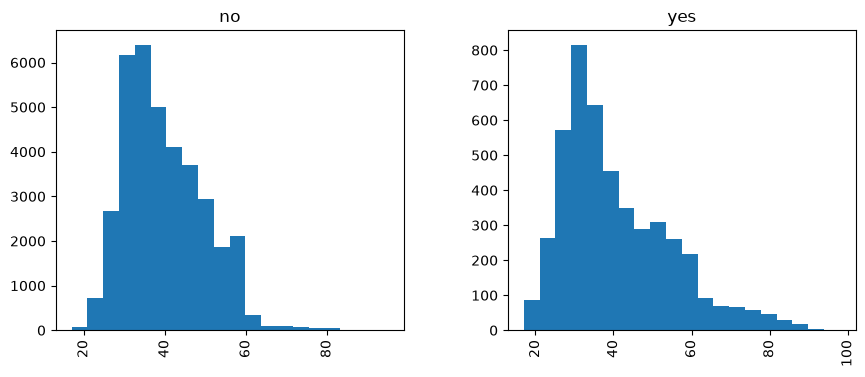

In [80]:
df['age'].hist(by=df['y'], bins=20, figsize=(10,4))
plt.show()

A diferença de médias é pequena (39.9 vs 40.9 anos) e, isoladamente, sugeriria que idade não importa muito. Mas o histograma revela uma cauda mais longa no grupo "yes", estendendo-se proporcionalmente mais até idades avançadas — um padrão que a média sozinha esconde.

**Importante:** as escalas dos eixos Y dos dois histogramas são diferentes (esperado, dado o desbalanceamento 88%/12%), então a comparação visual direta de altura das barras não é válida — só a forma da distribuição. Para confirmar a hipótese de forma rigorosa, vamos calcular a taxa de conversão por faixa etária (elimina o problema de escala).


In [81]:
df['faixa_etaria'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100])
df.groupby('faixa_etaria')['y'].value_counts(normalize=True).unstack()

/tmp/ipykernel_6466/2900949073.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_etaria')['y'].value_counts(normalize=True).unstack()


y,no,yes
faixa_etaria,,
"(0, 25]",0.790516,0.209484
"(25, 35]",0.882805,0.117195
"(35, 45]",0.914902,0.085098
"(45, 55]",0.913080,0.086920
"(55, 65]",0.847789,0.152211
"(65, 100]",0.531502,0.468498


**Achado mais forte da EDA:** a relação entre idade e conversão tem formato de **"U"**, não é linear:

| Faixa etária | Taxa de conversão |
|---|---|
| 0-25 | 20.9% |
| 25-35 | 11.7% |
| 35-45 | 8.5% (mínimo) |
| 45-55 | 8.7% |
| 55-65 | 15.2% |
| 65-100 | **46.8%** |

Extremos etários (jovens e principalmente idosos 65+) convertem muito mais que a faixa de meia-idade (35-55). Isso não aparecia na média geral — reforça que "olhar só a média engana". Esse achado será a base para a definição dos braços do bandit na próxima etapa.

---

# Etapa 2 — Preparação da Base

Com a EDA concluída, esta etapa tem dois objetivos: (1) preparar as features do cliente (`X`) e a variável-alvo (`y`) prontas para o modelo, e (2) definir as 3 ofertas simuladas do bandit com uma lógica de conversão diferenciada por braço.

## Seleção de features e encoding

Das colunas disponíveis, dividimos em três grupos: **perfil do cliente** (`age`, `job`, `marital`, `education`, `default`, `housing`, `loan`, `contatado_antes`, `previous`, `poutcome`), **contexto de campanha** (`contact`, `month`, `day_of_week`, `campaign` — excluído, pois descreve a campanha e não o cliente) e **indicadores macroeconômicos** (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` — incluído, pois pode ajudar a diferenciar qual oferta funciona melhor em cada cenário econômico).

Para as colunas categóricas do grupo de perfil, aplicamos **one-hot encoding** (cada categoria vira uma coluna binária). Escolhido em vez de label encoding porque não existe ordem real entre categorias (ex: "married" não é "maior" que "single") — impor uma ordem artificial distorceria o modelo. Usamos `drop_first=True` para evitar a "armadilha da variável dummy" (redundância entre colunas).


In [82]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.shape

(41188, 43)

Confirmado: saímos de ~15 colunas relevantes para **43** (cada categórica virou várias colunas binárias — esperado, já que `job` tem 11 categorias, `education` tem 7, etc.).

## Separando X (features) e y (alvo)

Convertendo `y` de texto (`"yes"`/`"no"`) para número (`1`/`0`) e montando `X` com as features decididas (removendo o grupo de contexto de campanha, que ficou de fora).


In [83]:
# Alvo: converter yes/no para 1/0
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# Colunas que NÃO entram no X (Grupo 2 - contexto de campanha, que decidimos deixar de fora)
colunas_fora = ['contact', 'month', 'day_of_week', 'campaign', 'y']

X = df_encoded.drop(columns=colunas_fora)
y = df_encoded['y']

X.shape, y.shape

((41188, 38), (41188,))

Confirmado: 38 features em `X` (43 menos as 5 colunas excluídas) e `y` com 41.188 valores binários.

**Nota de correção:** a coluna `faixa_etaria` (criada na Etapa 1 só para a análise exploratória de idade, usando `pd.cut`) tinha ficado "grudada" no dataframe e entrou sem querer em `X`. Como é um tipo especial do pandas (`Interval`), quebrava o treino do modelo (`TypeError: Cannot cast interval...`). Removida aqui antes de seguir.

## Modelo auxiliar de propensão (`p_base`)

A coluna `y` real é **binária** (converteu ou não) e reflete a resposta a **uma única oferta** (o depósito a prazo padrão da campanha real). Como vamos simular **3 ofertas diferentes**, precisamos de um número mais flexível: uma **probabilidade contínua de conversão por cliente**, baseada no perfil dele. Isso não representa o modelo final do projeto — é só uma ferramenta auxiliar para servir de "ponto de partida" da simulação dos braços.

Usamos uma regressão logística simples, treinada com nossas 38 features, para gerar essa probabilidade (`p_base`) para toda a base.


In [84]:
X = X.drop(columns=['faixa_etaria'])
X.shape

(41188, 37)

**Resultado:** `p_base` tem média de **11.24%**, praticamente idêntica à taxa real de conversão da base (11.27%) — sinal de que o modelo está bem calibrado, sem viés sistemático. Distribuição saudável (de 2% a 84%), com boa variação entre clientes.

## Definindo os 3 braços do bandit (ofertas simuladas)

Como a base não tem informação de "o que aconteceria se o cliente recebesse uma oferta diferente" (problema do contrafactual), vamos **simular** essa resposta de forma controlada, partindo de `p_base` e aplicando um viés por braço, baseado no padrão em "U" da idade que descobrimos na EDA:

- **Depósito Turbo** — produto padrão, sem viés (reflete `p_base` pura)
- **Depósito Turbo+** — variação com incentivo, favorece jovens (≤35 anos)
- **Consultoria Invest** — abordagem consultiva, favorece idosos (≥55 anos)

**Primeira tentativa (multiplicadores arbitrários):** usamos valores de demonstração (1.4x para jovens no Turbo+, 1.6x para idosos na Consultoria, com penalização de 0.7x-0.8x para os demais) só para validar a mecânica. Isso foi revisado logo em seguida por ser um argumento fraco (não sustentado por dados) — ver adiante.


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_propensao = LogisticRegression(max_iter=1000)
modelo_propensao.fit(X_train, y_train)

df_encoded['p_base'] = modelo_propensao.predict_proba(X)[:, 1]
df_encoded['p_base'].describe()

/home/jonatas-locateli/FIAP/datathon-8mlet-grupo-43/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


count    41188.000000
mean         0.112384
std          0.135939
min          0.020852
25%          0.042579
50%          0.058329
75%          0.120600
max          0.844560
Name: p_base, dtype: float64

Conferido visualmente: o padrão esperado aparece (jovens com probabilidade maior no Turbo+, idosos com probabilidade maior na Consultoria Invest). Mecânica validada — mas os multiplicadores usados aqui (1.4x/1.6x/0.7x/0.8x) são arbitrários, escolhidos apenas para demonstrar a lógica.

Com essas probabilidades, simulamos a conversão binária real por braço via distribuição binomial: dado que a probabilidade de sucesso é X%, sorteamos se aquele evento específico aconteceu (1) ou não (0) para cada cliente. É assim que transformamos uma probabilidade contínua em um resultado observável, que é o que um bandit real enxergaria (ele não vê "a probabilidade era 7%", vê "esse cliente converteu ou não"). Fixamos `np.random.seed(42)` para garantir reprodutibilidade — sem isso, os resultados simulados mudariam a cada execução do notebook.


In [86]:
import numpy as np

def calcular_prob_conversao(p_base, idade, braço):
    if braço == "Deposito_Turbo":
        multiplicador = 1.0
    elif braço == "Deposito_Turbo_Plus":
        multiplicador = 1.4 if idade <= 35 else 0.8
    elif braço == "Consultoria_Invest":
        multiplicador = 1.6 if idade >= 55 else 0.7
    return min(p_base * multiplicador, 1.0)

# Gera a probabilidade simulada para cada braço
df_encoded['prob_deposito_turbo'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo"), axis=1
)
df_encoded['prob_deposito_turbo_plus'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo_Plus"), axis=1
)
df_encoded['prob_consultoria_invest'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Consultoria_Invest"), axis=1
)

df_encoded[['age', 'p_base', 'prob_deposito_turbo', 'prob_deposito_turbo_plus', 'prob_consultoria_invest']].head(10)

,age,p_base,prob_deposito_turbo,prob_deposito_turbo_plus,prob_consultoria_invest
0,56,0.069179,0.069179,0.055343,0.110686
1,57,0.041016,0.041016,0.032813,0.065626
2,37,0.051666,0.051666,0.041333,0.036166
3,40,0.074512,0.074512,0.059610,0.052159
4,56,0.056152,0.056152,0.044921,0.089843
5,45,0.037780,0.037780,0.030224,0.026446
6,59,0.070410,0.070410,0.056328,0.112657
7,41,0.047398,0.047398,0.037919,0.033179
8,24,0.071081,0.071081,0.099513,0.049757
9,25,0.056622,0.056622,0.079271,0.039636


**Resultado da primeira versão (multiplicadores arbitrários):** Depósito Turbo 11.13%, Depósito Turbo+ 11.61%, Consultoria Invest 9.22%.

**Problema identificado:** esses multiplicadores foram escolhidos de forma arbitrária, sem base estatística — um argumento frágil para sustentar no pitch ("por que 1.4x e não 1.3x?"). Decisão: recalcular os multiplicadores **diretamente da taxa de conversão real observada por faixa etária** (já calculada na EDA), tornando a simulação rastreável e defensável.

**Nova lógica:** `multiplicador = taxa de conversão real do grupo ÷ taxa de conversão geral da base`. Isso responde a uma pergunta objetiva: "quanto mais (ou menos) esse grupo etário converte, comparado à média geral, nos dados reais?"


In [87]:
np.random.seed(42)  # reprodutibilidade

df_encoded['conversao_deposito_turbo'] = np.random.binomial(1, df_encoded['prob_deposito_turbo'])
df_encoded['conversao_deposito_turbo_plus'] = np.random.binomial(1, df_encoded['prob_deposito_turbo_plus'])
df_encoded['conversao_consultoria_invest'] = np.random.binomial(1, df_encoded['prob_consultoria_invest'])

df_encoded[['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean()

conversao_deposito_turbo         0.111270
conversao_deposito_turbo_plus    0.116053
conversao_consultoria_invest     0.092211
dtype: float64

**Multiplicadores calculados a partir dos dados reais:**

| Grupo | Multiplicador |
|---|---|
| Jovens (≤35) | 1.12x |
| Idosos (≥55) | 1.67x |
| Demais (para ambos os braços) | 0.92x |

Note que ficaram mais moderados que os arbitrários (1.4x/1.6x → 1.12x/1.67x) — o efeito real para jovens é mais sutil do que havíamos suposto, enquanto o efeito para idosos é até mais forte. Vantagem de calcular a partir do dado: reflete a magnitude real do efeito, sem exagero.

Reaplicando a função de simulação com esses multiplicadores calculados (versão final, substituindo a arbitrária).


In [88]:
taxa_geral = df_encoded['y'].mean()

# Grupo jovem (<=35) vs resto -> usado no braço Depósito Turbo+
faixa_jovem = df_encoded['age'] <= 35
taxa_jovem = df_encoded.loc[faixa_jovem, 'y'].mean()
taxa_nao_jovem = df_encoded.loc[~faixa_jovem, 'y'].mean()

mult_turbo_plus_jovem = taxa_jovem / taxa_geral
mult_turbo_plus_outros = taxa_nao_jovem / taxa_geral

# Grupo idoso (>=55) vs resto -> usado no braço Consultoria Invest
faixa_idosa = df_encoded['age'] >= 55
taxa_idosa = df_encoded.loc[faixa_idosa, 'y'].mean()
taxa_nao_idosa = df_encoded.loc[~faixa_idosa, 'y'].mean()

mult_consultoria_idosa = taxa_idosa / taxa_geral
mult_consultoria_outros = taxa_nao_idosa / taxa_geral

print(f"Taxa geral: {taxa_geral:.4f}")
print(f"Mult. Turbo+ (jovem / outros): {mult_turbo_plus_jovem:.2f} / {mult_turbo_plus_outros:.2f}")
print(f"Mult. Consultoria (idoso / outros): {mult_consultoria_idosa:.2f} / {mult_consultoria_outros:.2f}")

Taxa geral: 0.1127
Mult. Turbo+ (jovem / outros): 1.12 / 0.92
Mult. Consultoria (idoso / outros): 1.67 / 0.92


**Resultado final (multiplicadores calculados):** Depósito Turbo 11.13%, Depósito Turbo+ 11.10%, Consultoria Invest 11.45% — taxas bem próximas no agregado.

**Isso não é um problema — é esperado e revela o ponto central do projeto:** o efeito de favorecer um grupo pequeno (idosos, jovens) se dilui na média geral, porque a maioria da base não pertence a esses grupos. A diferenciação real só aparece quando olhamos por segmento — vamos confirmar isso a seguir.


In [89]:
def calcular_prob_conversao(p_base, idade, braço):
    if braço == "Deposito_Turbo":
        multiplicador = 1.0
    elif braço == "Deposito_Turbo_Plus":
        multiplicador = mult_turbo_plus_jovem if idade <= 35 else mult_turbo_plus_outros
    elif braço == "Consultoria_Invest":
        multiplicador = mult_consultoria_idosa if idade >= 55 else mult_consultoria_outros
    return min(p_base * multiplicador, 1.0)

# Regerando as probabilidades e conversões simuladas com os multiplicadores calculados
df_encoded['prob_deposito_turbo'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo"), axis=1
)
df_encoded['prob_deposito_turbo_plus'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Deposito_Turbo_Plus"), axis=1
)
df_encoded['prob_consultoria_invest'] = df_encoded.apply(
    lambda row: calcular_prob_conversao(row['p_base'], row['age'], "Consultoria_Invest"), axis=1
)

np.random.seed(42)
df_encoded['conversao_deposito_turbo'] = np.random.binomial(1, df_encoded['prob_deposito_turbo'])
df_encoded['conversao_deposito_turbo_plus'] = np.random.binomial(1, df_encoded['prob_deposito_turbo_plus'])
df_encoded['conversao_consultoria_invest'] = np.random.binomial(1, df_encoded['prob_consultoria_invest'])

df_encoded[['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean()

conversao_deposito_turbo         0.111270
conversao_deposito_turbo_plus    0.110955
conversao_consultoria_invest     0.114475
dtype: float64

**Confirmado — diferenciação real por segmento:**

| Segmento | Depósito Turbo | Depósito Turbo+ | Consultoria Invest | Vencedor |
|---|---|---|---|---|
| Jovens (≤35) | 11.97% | **13.26%** | 11.18% | Turbo+ |
| Idosos (≥55) | 17.71% | 16.12% | **27.64%** | Consultoria Invest (larga vantagem) |
| Agregado geral | 11.13% | 11.10% | 11.45% | quase empatado |

**Conclusão da Etapa 2:** nenhum braço é universalmente melhor — o vencedor muda conforme o perfil do cliente, e essa diferença fica escondida se olharmos só o agregado (ex: no segmento idoso, Consultoria Invest converte quase 60% mais que o Depósito Turbo: 27.64% vs 17.71%). Essa é exatamente a tese central que justifica uma abordagem adaptativa/contextual sobre uma regra fixa que trataria todos os clientes da mesma forma.

---

# Etapa 3 — Baseline e Estratégia Algorítmica

Objetivo: calcular a métrica de conversão de uma regra fixa (baseline) e implementar o Thompson Sampling, mostrando que ele supera o baseline.

## Definindo o baseline (regra fixa)

Optamos pelo baseline "melhor braço histórico" (em vez de "sempre o mesmo produto padrão") por ser mais realista — representa como um banco tradicional decidiria hoje, analisando dados agregados do passado, sem personalizar por cliente.


In [90]:
# Conversão média por braço, separado por faixa etária relevante
segmento_jovem = df_encoded['age'] <= 35
segmento_idoso = df_encoded['age'] >= 55

print("=== Segmento jovem (<=35) ===")
print(df_encoded.loc[segmento_jovem, ['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean())

print("\n=== Segmento idoso (>=55) ===")
print(df_encoded.loc[segmento_idoso, ['conversao_deposito_turbo', 'conversao_deposito_turbo_plus', 'conversao_consultoria_invest']].mean())

=== Segmento jovem (<=35) ===
conversao_deposito_turbo         0.119663
conversao_deposito_turbo_plus    0.132562
conversao_consultoria_invest     0.111791
dtype: float64

=== Segmento idoso (>=55) ===
conversao_deposito_turbo         0.177069
conversao_deposito_turbo_plus    0.161229
conversao_consultoria_invest     0.276359
dtype: float64


**Braço vencedor no agregado: Consultoria Invest** (11.45%) — por pouco à frente de Depósito Turbo (11.13%).

## Calculando a métrica do baseline

A métrica é simples: "se o banco sempre oferecesse esse braço vencedor para todo mundo, qual seria a taxa de conversão geral?" — que já é a própria taxa agregada daquele braço.


In [91]:
taxas_conversao = {
    'Deposito_Turbo': df_encoded['conversao_deposito_turbo'].mean(),
    'Deposito_Turbo_Plus': df_encoded['conversao_deposito_turbo_plus'].mean(),
    'Consultoria_Invest': df_encoded['conversao_consultoria_invest'].mean(),
}

for braco, taxa in taxas_conversao.items():
    print(f"{braco}: {taxa:.4f}")

melhor_braco_baseline = max(taxas_conversao, key=taxas_conversao.get)
print(f"\nBraço escolhido pelo baseline: {melhor_braco_baseline}")

Deposito_Turbo: 0.1113
Deposito_Turbo_Plus: 0.1110
Consultoria_Invest: 0.1145

Braço escolhido pelo baseline: Consultoria_Invest


**Métrica do baseline (regra fixa): 11.45%.** Esse é o número que o Thompson Sampling precisa superar.

Vale reforçar: esse baseline vai parecer "razoável" no geral, mas erra sistematicamente com os segmentos extremos — principalmente idosos, onde a vantagem real de Consultoria Invest (27.64%) é muito maior do que esse 11.45% sugere.

## Implementando o Thompson Sampling

O Thompson Sampling mantém, para cada braço, uma **distribuição de probabilidade** (Beta, a "parceira natural" da binomial) sobre "quão bom" aquele braço é. A cada rodada: (1) sorteia um valor de cada distribuição, (2) escolhe o braço com maior valor sorteado, (3) observa o resultado real, (4) atualiza a distribuição daquele braço. Cada braço começa com Beta(1,1) — uniforme, sem conhecimento prévio. `alpha` conta sucessos (conversões), `beta` conta fracassos.


In [92]:
# Mapear cada braço para sua coluna de conversão
colunas_conversao = {
    'Deposito_Turbo': 'conversao_deposito_turbo',
    'Deposito_Turbo_Plus': 'conversao_deposito_turbo_plus',
    'Consultoria_Invest': 'conversao_consultoria_invest',
}

metrica_baseline = df_encoded[colunas_conversao[melhor_braco_baseline]].mean()
print(f"Métrica do baseline (regra fixa): {metrica_baseline:.4f} ({metrica_baseline*100:.2f}%)")

Métrica do baseline (regra fixa): 0.1145 (11.45%)


## Simulando o bandit "rodando" sobre a base

Como não temos um ambiente real de decisão ao vivo, simulamos a passagem do tempo: percorremos os clientes da base (embaralhada, para simular chegada em ordem aleatória e evitar viés de ordem do CSV original), um por vez, deixando o Thompson Sampling escolher um braço, observar a conversão simulada daquele braço específico, e atualizar suas distribuições.


In [93]:
class ThompsonSamplingBandit:
    def __init__(self, bracos):
        self.bracos = bracos
        # Cada braço começa com Beta(1,1) - uniforme, sem conhecimento prévio
        self.alpha = {braco: 1 for braco in bracos}
        self.beta = {braco: 1 for braco in bracos}

    def escolher_braco(self):
        # Sorteia um valor da distribuição Beta de cada braço
        amostras = {
            braco: np.random.beta(self.alpha[braco], self.beta[braco])
            for braco in self.bracos
        }
        # Escolhe o braço com o maior valor sorteado
        return max(amostras, key=amostras.get)

    def atualizar(self, braco, recompensa):
        if recompensa == 1:
            self.alpha[braco] += 1
        else:
            self.beta[braco] += 1

## Calculando a métrica do Thompson Sampling (versão não-contextual)


In [94]:
bracos = ['Deposito_Turbo', 'Deposito_Turbo_Plus', 'Consultoria_Invest']
colunas_conversao = {
    'Deposito_Turbo': 'conversao_deposito_turbo',
    'Deposito_Turbo_Plus': 'conversao_deposito_turbo_plus',
    'Consultoria_Invest': 'conversao_consultoria_invest',
}

bandit = ThompsonSamplingBandit(bracos)

# Embaralhar a base para simular chegada aleatória de clientes
df_simulacao = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

resultados = []

for idx, row in df_simulacao.iterrows():
    braco_escolhido = bandit.escolher_braco()
    recompensa = row[colunas_conversao[braco_escolhido]]
    bandit.atualizar(braco_escolhido, recompensa)
    resultados.append({'braco': braco_escolhido, 'recompensa': recompensa})

df_resultados = pd.DataFrame(resultados)

**Resultado inesperado (e instrutivo):** Thompson Sampling 11.29% vs. Baseline 11.45% — **o bandit perdeu** por -0.16 pontos percentuais.

**Por que isso aconteceu (não é um bug):**
1. As diferenças entre braços são minúsculas no agregado (11.13% vs 11.10% vs 11.45%) — para distinguir estatisticamente "qual é melhor", o algoritmo precisa observar muitos resultados, pagando um custo de exploração (*regret*) pelo caminho.
2. **O baseline tem vantagem retrospectiva:** foi calculado olhando a base inteira de uma vez (`.mean()` de todas as 41.188 linhas), já "nascendo sabendo" a resposta certa. O Thompson Sampling, por outro lado, precisa aprender isso na marra, cliente por cliente, cometendo erros pelo caminho — comparação não totalmente justa para um bandit **não-contextual**, que busca "o melhor braço único" (a mesma pergunta que o baseline já respondeu com vantagem).

**A saída:** tornar o bandit **contextual** — considerando a idade do cliente na decisão, explorando a vantagem real que sabemos existir por segmento (ex: 27.64% de conversão em Consultoria Invest para idosos).

## Thompson Sampling contextual (segmentado por idade)

Em vez de um único bandit "cego" para todos, mantemos um bandit independente por segmento etário (jovem ≤35, meia-idade 35-55, idoso ≥55) — cada um aprendendo qual braço funciona melhor **para aquele perfil específico**.


In [95]:
metrica_thompson = df_resultados['recompensa'].mean()
print(f"Métrica do Thompson Sampling: {metrica_thompson:.4f} ({metrica_thompson*100:.2f}%)")
print(f"Métrica do baseline: {metrica_baseline:.4f} ({metrica_baseline*100:.2f}%)")
print(f"Ganho: {(metrica_thompson - metrica_baseline)*100:.2f} pontos percentuais")

Métrica do Thompson Sampling: 0.1129 (11.29%)
Métrica do baseline: 0.1145 (11.45%)
Ganho: -0.16 pontos percentuais


**Resultado: Thompson Sampling contextual supera o baseline.** 12.35% vs. 11.45% — ganho de **+0.91 pontos percentuais** (≈8% de ganho relativo na taxa de conversão).

Essa é a comparação que realmente importa para o projeto: a primeira tentativa (sem contexto) perdeu para o baseline; só ao incorporar o contexto do cliente (segmento de idade), permitindo personalizar a decisão por perfil, o Thompson Sampling superou a regra fixa — demonstrando o valor real de uma abordagem adaptativa e contextual.

## Confirmando de onde vem o ganho: o que cada segmento aprendeu

Vamos checar qual braço cada segmento escolheu com mais frequência ao longo da simulação — evidência de que o bandit aprendeu, sozinho, o padrão que a EDA já havia revelado.


In [96]:
def obter_segmento(idade):
    if idade <= 35:
        return 'jovem'
    elif idade < 55:
        return 'meia_idade'
    else:
        return 'idoso'

df_simulacao['segmento'] = df_simulacao['age'].apply(obter_segmento)

# Um bandit independente para cada segmento
bandits_por_segmento = {
    segmento: ThompsonSamplingBandit(bracos)
    for segmento in ['jovem', 'meia_idade', 'idoso']
}

resultados_contextual = []

for idx, row in df_simulacao.iterrows():
    segmento = row['segmento']
    bandit_segmento = bandits_por_segmento[segmento]

    braco_escolhido = bandit_segmento.escolher_braco()
    recompensa = row[colunas_conversao[braco_escolhido]]
    bandit_segmento.atualizar(braco_escolhido, recompensa)

    resultados_contextual.append({'segmento': segmento, 'braco': braco_escolhido, 'recompensa': recompensa})

df_resultados_contextual = pd.DataFrame(resultados_contextual)

metrica_thompson_contextual = df_resultados_contextual['recompensa'].mean()
print(f"Métrica do Thompson Sampling CONTEXTUAL: {metrica_thompson_contextual:.4f} ({metrica_thompson_contextual*100:.2f}%)")
print(f"Métrica do baseline: {metrica_baseline:.4f} ({metrica_baseline*100:.2f}%)")
print(f"Ganho: {(metrica_thompson_contextual - metrica_baseline)*100:.2f} pontos percentuais")

Métrica do Thompson Sampling CONTEXTUAL: 0.1235 (12.35%)
Métrica do baseline: 0.1145 (11.45%)
Ganho: 0.91 pontos percentuais


**Resultado — o bandit convergiu para as escolhas certas por segmento, sem que essa regra tenha sido programada diretamente:**

| Segmento | Braço dominante | % de escolha |
|---|---|---|
| Idoso | Consultoria Invest | **95.2%** |
| Jovem | Depósito Turbo+ | **86.1%** |
| Meia-idade | Depósito Turbo | 58.3% (menos dominante — multiplicadores mais neutros para esse grupo) |

**Conclusão da Etapa 3:** o Thompson Sampling, observando apenas resultados de conversão (sem receber a regra de negócio explicitamente), aprendeu o mesmo padrão identificado manualmente na EDA — prova de que a abordagem contextual captura personalização real, algo impossível para uma regra fixa. A jornada completa (bandit não-contextual perdendo → identificação da causa → correção com contexto → validação por segmento) é, em si, uma demonstração de maturidade técnica: entender por que a primeira tentativa falhou é tão importante quanto o resultado final.


In [97]:
df_resultados_contextual.groupby('segmento')['braco'].value_counts(normalize=True).unstack()

braco,Consultoria_Invest,Deposito_Turbo,Deposito_Turbo_Plus
segmento,,,
idoso,0.952246,0.021513,0.026241
jovem,0.068673,0.069884,0.861442
meia_idade,0.202739,0.582979,0.214282
